In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Load data
df = pd.read_excel("ppp_bank_data_cleaned.xlsx")

In [2]:
# Model 1
features_1 = [
    "balance_frequency",
    "purchases_frequency",
    "purchases_trx",
    "purchases",
    "cash_advance_trx"
]

X1 = df[features_1]

scaler1 = StandardScaler()
X1_scaled = scaler1.fit_transform(X1)


In [3]:
kmeans1 = KMeans(n_clusters=4, random_state=42, n_init=10)
df["cluster_model_1"] = kmeans1.fit_predict(X1_scaled)

cluster_names_1 = {
    0: "Passive Credit Users",
    1: "Highly Active Users",
    2: "Active Users",
    3: "Passive Low Users"
}

df["segment_model_1"] = df["cluster_model_1"].map(cluster_names_1)


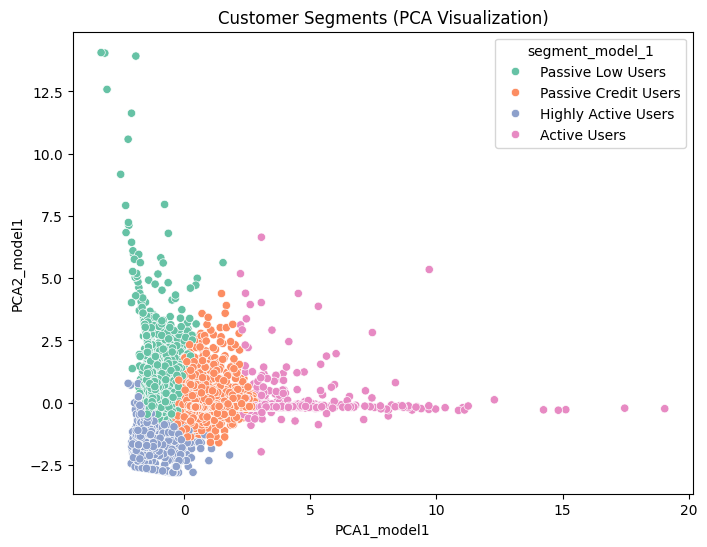

In [4]:
pca1 = PCA(n_components=2)
pca1_data = pca1.fit_transform(X1_scaled)

df["PCA1_model1"] = pca1_data[:, 0]
df["PCA2_model1"] = pca1_data[:, 1]

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x="PCA1_model1",
    y="PCA2_model1",
    hue="segment_model_1",
    palette="Set2"
)

plt.title("Customer Segments (PCA Visualization)")
plt.show()


In [5]:
# Model 2
features_2 = [
    "purchases_frequency",
    "balance_frequency",
    "cash_advance_frequency",
    "purchases_installments_frequency",
    "oneoff_purchases_frequency"
]

X2 = df[features_2]

scaler2 = StandardScaler()
X2_scaled = scaler2.fit_transform(X2)


In [6]:
kmeans2 = KMeans(n_clusters=5, random_state=42, n_init=10)
df["cluster_model_2"] = kmeans2.fit_predict(X2_scaled)

cluster_names_2 = {
    0: "Swipe addicts",
    1: "Cash hunters",
    2: "Sleeping accounts",
    3: "Barely there",
    4: "Split payers"
}

df["segment_model_2"] = df["cluster_model_2"].map(cluster_names_2)


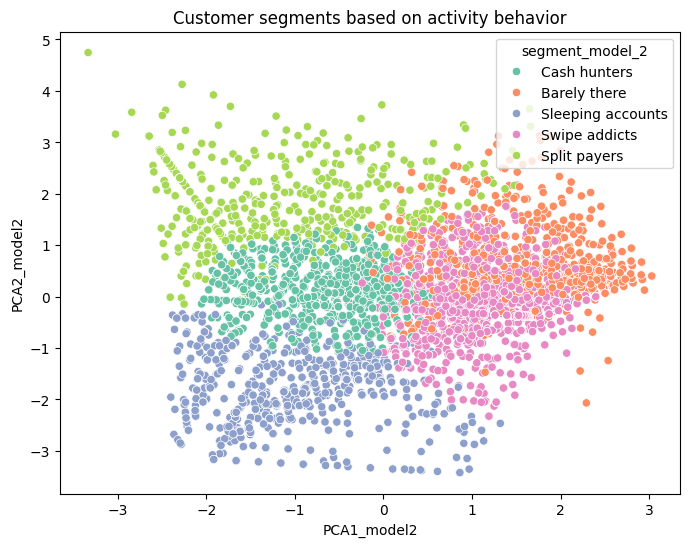

In [7]:
pca2 = PCA(n_components=2)
pca2_data = pca2.fit_transform(X2_scaled)

df["PCA1_model2"] = pca2_data[:, 0]
df["PCA2_model2"] = pca2_data[:, 1]

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x="PCA1_model2",
    y="PCA2_model2",
    hue="segment_model_2",
    palette="Set2"
)

plt.title("Customer segments based on activity behavior")
plt.show()


In [8]:
df.to_excel("ppp_bank_data_with_clusters.xlsx", index=False)